# The receiver case — 1y1y outright and the 1y/1y1y flattener

The chart JWS builds his front-end call on is a dislocation: the **economic
surprise indices pushed forward** against a **Fed-speak sentiment index**. When
the data rolls over and Fedspeak has not yet followed, his read is that the
committee converges to the data and the front end rallies.

This notebook puts that chart next to the instrument and asks the only
question a position depends on: **does the dislocation say anything about
1y1y, and is the outright or the flattener the better way to hold it?**

The useful property of a *lead* is that the right-hand side of the regression
for the next several months is **already observed**. That is what §2 draws and
§3c measures, and it is the whole of the receiver's case here — not a residual.

In [1]:
%load_ext autoreload
%autoreload 2

import nest_asyncio
nest_asyncio.apply()

import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
plt.style.use("ggplot")
pylab.rcParams.update({
    "legend.fontsize": "medium", "figure.figsize": (18, 6),
    "axes.labelsize": "medium", "axes.titlesize": "medium",
    "xtick.labelsize": "medium", "ytick.labelsize": "medium",
})

import datetime
import os
import sys
import warnings

import numpy as np
import pandas as pd
import pytz
import statsmodels.api as sm

warnings.filterwarnings("ignore")
os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")
NYC_tz = pytz.timezone("America/New_York")
sys.path.append("../../")
sys.path.append("../rv")

from RVUtils.plt_timeseries import make_secondary_axis_plot
from RVUtils.regression import make_linear_regression_builder

In [2]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from TB.IRSwapsTB import IRSwapsTB
from Query.Unified.UnifiedQuery import UnifiedQuery
from Query.Unified.registry import UnifiedValue
from TB.TimeseriesBuilder import TimeseriesBuilder

curve_mdp = IRSwapsMDP(source="citivelo_excel_rl")

#: The rate legs go back as far as the curve store serves. Only the *sentiment*
#: series is short (the JPM NLP corpus starts 2023-05), and only Chart 1 needs
#: it — so the regressions get 11 years and the chart gets 3.
RATE_START = datetime.date(2015, 1, 1)
SENT_START = datetime.date(2023, 5, 1)
END = datetime.date(2026, 8, 24)

## 1. The two sides of the JWS chart

`fed_expected_sentiment` builds the surprise composite: two daily Citi CESI
sub-indices — **labour market** and **prices / money supply** — each trailing
z-scored over 756 business days, equal-weighted, NaN on any day either leg is
missing. `fed_event_conditioning` builds the Fed sentiment index: a
calendar-time EWMA over the JPM NLP hawk/dove scores with a 21-day half-life,
**publication-gated**, so a speech only enters the index once the report that
scored it existed.

In [3]:
import dataclasses

import fed_expected_sentiment as E
import fed_event_conditioning as FEC

zc, comp_prov = E.load_composite()                      # weekly W-FRI, z-scored
zc = zc.dropna()
cfg = dataclasses.replace(FEC.PRIMARY, source="jpm")
sent_df, scores = FEC.load_daily_sentiment(cfg, str(SENT_START), str(END))
sent = sent_df["sentiment"].dropna()                    # raw index, the JWS scale

print(f"surprise composite : {zc.index.min().date()}..{zc.index.max().date()}"
      f"  ({len(zc)} weeks)   last {zc.iloc[-1]:+.3f}")
print(f"fed sentiment (PIT): {sent.index.min().date()}..{sent.index.max().date()}"
      f"  ({len(sent)} days)   last {sent.iloc[-1]:+.2f}")
print(f"\nsurprise legs: {comp_prov.get('legs')}")

surprise composite : 2004-12-10..2026-08-21  (1133 weeks)   last -0.373
fed sentiment (PIT): 2023-05-03..2026-08-24  (864 days)   last +29.65

surprise legs: ['labour_market_raw', 'labour_market_z', 'prices_or_money_supply_raw', 'prices_or_money_supply_z']


### Chart 1 — the dislocation

The composite is pushed **forward** so it lines up with the Fedspeak it is
supposed to lead. JWS uses **5 weeks**; the measured lead on this data is
**11–14 weeks**, so both are drawn.

The shift is on the **index**, not on positions. A positional `.shift(11)`
against a fixed index silently drops the newest eleven composite readings off
the end — which here are exactly the rolled-over ones the trade is about. Done
on the index instead, the pushed line **extends past** the sentiment series,
and that overhang is the part of the regressor that is already known.

In [ ]:
LEAD_JWS, LEAD_MEASURED = 5, 11


def pushed(s: pd.Series, weeks: int) -> pd.Series:
    """Push a W-FRI series forward `weeks`, EXTENDING the index rather than
    truncating it. `freq="7D"` is exact on a weekly grid."""
    return s.shift(weeks, freq="7D")


_win = zc.index >= pd.Timestamp(SENT_START) - pd.Timedelta(weeks=LEAD_MEASURED + 4)
zc_win = zc[_win]

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="plotly",
    ylabel_left="surprise composite, z (pushed forward)",
    ylabel_right="Fed sentiment index (hawkish +)",
    # title="Surprise indices pushed forward vs Fed-speak sentiment "
    #       "— the pushed lines run past the sentiment, and that overhang is known",
)
plot(pushed(zc_win, LEAD_JWS), label=f"composite, pushed fwd {LEAD_JWS}w (JWS)",
     which="left")
plot(pushed(zc_win, LEAD_MEASURED),
     label=f"composite, pushed fwd {LEAD_MEASURED}w (measured)", which="left")
plot(sent, label="Fed sentiment, point-in-time", which="right")
legend(show_date=True)

# print(f"sentiment ends {sent.index.max().date()}; the {LEAD_MEASURED}w-pushed "
#       f"composite runs to {pushed(zc_win, LEAD_MEASURED).index.max().date()} "
#       f"-- {LEAD_MEASURED} weeks of the regressor are already observed.")

In [49]:
jpm = pd.read_csv(r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\global_hawk_dove_scores.csv")
jpm["date"] = pd.to_datetime(jpm["date"], errors="coerce")	
jpm = jpm.sort_values("date")
jpm = jpm[jpm["date"] > pd.Timestamp("2023-05-01")]
# display(jpm[jpm["central_bank"] == "FED"].tail(50))

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="plotly",
	ylabel_left="sentiment index (hawkish +)",
)


# plot(jpm[jpm["speaker"] == "Goolsbee"].set_index("date")["hawk_dove_score"], label="goolsbee", which="left")
# plot(jpm[jpm["speaker"] == "Daly"].set_index("date")["hawk_dove_score"].ewm(alpha=0.3, adjust=False).mean().ffill(), label="daly", which="left")

plot(jpm[jpm["speaker"] == "Hammack"].set_index("date")["hawk_dove_score"].ewm(alpha=0.3, adjust=False).mean(), label="Hammack", which="left")
plot(jpm[jpm["speaker"] == "Kashkari"].set_index("date")["hawk_dove_score"].ewm(alpha=0.3, adjust=False).mean(), label="Kashkari", which="left")
plot(jpm[jpm["speaker"] == "Logan"].set_index("date")["hawk_dove_score"].ewm(alpha=0.3, adjust=False).mean(), label="Logan", which="left")
plot(jpm[jpm["speaker"] == "Schmid"].set_index("date")["hawk_dove_score"].ewm(alpha=0.3, adjust=False).mean(), label="Schmid", which="left")
# plot(jpm[jpm["speaker"] == "Waller"].set_index("date")["hawk_dove_score"].ewm(alpha=0.3, adjust=False).mean(), label="Waller", which="left")


plot(jpm[jpm["central_bank"] == "FED"].set_index("date")["hawk_dove_score"].ewm(alpha=0.05, adjust=False).mean(), label="avg", which="left")
legend(show_date=True)

## 2. The instrument

1y1y is the cleanest single expression of "the Fed does less than priced over
the next couple of years" — behind the meetings that are nearly resolved, in
front of the terminal-rate debate. The **1y/1y1y** curve is the same view held
as a flattener: receive 1y1y, pay 1y.

Watch the units. A one-leg `IRS_RATE` comes back in **percent**; a two-leg
curve comes back in **bp**.

In [5]:
tb = TimeseriesBuilder(irswaps_tb=IRSwapsTB(curve_mdp, show_tqdm=False))

rates = tb.get_timeseries(
    start=RATE_START,
    end=END,
    queries=[
        UnifiedQuery(curve="USD-SOFR-1D", tenor="1y1y", value=UnifiedValue.IRS_RATE),
        UnifiedQuery(curve="USD-SOFR-1D", tenor="1y/1y1y", value=UnifiedValue.IRS_RATE),
        UnifiedQuery(curve="USD-SOFR-1D", tenor="2y1y", value=UnifiedValue.IRS_RATE),
    ],
)
# TimeseriesBuilder hands back a plain Index of dates; resample() and every
# freq-shifted join below need a DatetimeIndex, and the failure would surface as
# a TypeError several cells later rather than here.
rates.index = pd.to_datetime(rates.index)

R_1Y1Y = "USD-SOFR-1D 1y1y OUTRIGHT RATE"
C_1Y_1Y1Y = "USD-SOFR-1D 1y/1y1y CURVE RATE"
R_2Y1Y = "USD-SOFR-1D 2y1y OUTRIGHT RATE"

print(f"{len(rates)} sessions {rates.index.min().date()}..{rates.index.max().date()}")
print(rates.dropna(how="all").tail(3).to_string())
print(f"\n1y1y is in PERCENT, the 1y/1y1y curve in BP "
      f"(last {rates[R_1Y1Y].dropna().iloc[-1]:.3f}% and "
      f"{rates[C_1Y_1Y1Y].dropna().iloc[-1]:+.1f}bp)")

2912 sessions 2015-01-02..2026-08-24
            USD-SOFR-1D 1y/1y1y CURVE RATE  USD-SOFR-1D 1y1y OUTRIGHT RATE  USD-SOFR-1D 2y1y OUTRIGHT RATE
Date                                                                                                      
2026-08-20                       13.420015                        4.113080                        4.114944
2026-08-21                       14.528154                        4.160192                        4.153935
2026-08-24                       12.619046                        4.157080                        4.128884

1y1y is in PERCENT, the 1y/1y1y curve in BP (last 4.157% and +12.6bp)


### Chart 2 — the signal against the instrument

The same composite pushed forward at the measured lead, against 1y1y. This is
the chart the position depends on, and the reason is the **right-hand end**:
the pushed line continues for eleven weeks after the rate line stops. Nothing
about that continuation is a forecast — it is data already printed, drawn at
the date it is supposed to matter.

In [6]:
CHART_FROM = pd.Timestamp("2022-01-01")
zc_c2 = zc[zc.index >= CHART_FROM - pd.Timedelta(weeks=LEAD_MEASURED)]

plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="plotly",
    ylabel_left=f"surprise composite, z (pushed fwd {LEAD_MEASURED}w)",
    ylabel_right="1y1y, %",
    title="The signal against 1y1y — the last 11 weeks of the pushed line are "
          "already observed",
)
plot(pushed(zc_c2, LEAD_MEASURED), label=f"composite, pushed fwd {LEAD_MEASURED}w",
     which="left")
plot(rates.loc[rates.index >= CHART_FROM, R_1Y1Y].dropna(), label="1y1y, %",
     which="right")
legend(show_date=True)

In [7]:
plot, fig, ax, ax2, legend = make_secondary_axis_plot(
    engine="plotly",
    ylabel_left=f"surprise composite, z (pushed fwd {LEAD_MEASURED}w)",
    ylabel_right="1y/1y1y, bp",
    title="The signal against the 1y/1y1y curve — positive = upward sloping",
)
plot(pushed(zc_c2, LEAD_MEASURED), label=f"composite, pushed fwd {LEAD_MEASURED}w",
     which="left")
plot(rates.loc[rates.index >= CHART_FROM, C_1Y_1Y1Y].dropna(), label="1y/1y1y, bp",
     which="right")
legend(show_date=True)

## 3. The regressions

On a **weekly** grid, not daily. The composite only updates weekly, so a daily
regression would repeat each observation five times and report an `n` five
times larger than the information in it.

In [8]:
W = rates.resample("W-FRI").last()
reg_df = W.join(zc.rename("SURPRISE_Z"), how="left")
reg_df["SURPRISE_Z_L11"] = zc.shift(LEAD_MEASURED).reindex(W.index)
reg_df["SURPRISE_Z_L5"] = zc.shift(LEAD_JWS).reindex(W.index)
reg_df["ONE_Y_ONE_Y_BP"] = reg_df[R_1Y1Y] * 100.0
reg_df = reg_df.dropna(subset=[R_1Y1Y, "SURPRISE_Z_L11"])
print(f"{len(reg_df)} weekly observations, "
      f"{reg_df.index.min().date()}..{reg_df.index.max().date()}")
reg_df.tail(3)

608 weekly observations, 2015-01-02..2026-08-21


,USD-SOFR-1D 1y/1y1y CURVE RATE,USD-SOFR-1D 1y1y OUTRIGHT RATE,USD-SOFR-1D 2y1y OUTRIGHT RATE,SURPRISE_Z,SURPRISE_Z_L11,SURPRISE_Z_L5,ONE_Y_ONE_Y_BP
Date,,,,,,,
2026-08-07,8.257816,4.092028,4.049040,-0.275451,0.632047,0.527488,409.202816
2026-08-14,11.899299,4.090633,4.087868,-0.429485,0.581153,0.633207,409.063299
2026-08-21,14.528154,4.160192,4.153935,-0.373219,1.163881,-0.000523,416.019154


In [9]:
def hac(df: pd.DataFrame, ycol: str, xcol: str, maxlags: int):
    """Refit one regressor by OLS with Newey-West errors.

    The builder has no `cov_type`, and every levels/overlapping fit here has
    residual autocorrelation heavy enough that the plain t is fiction. Same
    design matrix, honest standard error."""
    d = df[[ycol, xcol]].dropna()
    return sm.OLS(d[ycol], sm.add_constant(d[xcol])).fit(
        cov_type="HAC", cov_kwds={"maxlags": maxlags})

### 3a. 1y1y on the pushed-forward composite, in levels

A positive slope would be the claim: hot data at the lead, higher 1y1y; a
composite that has rolled over implies a lower 1y1y.

**It comes out negative, and insignificant.** On the full 2015–2026 sample the
levels slope is about −0.08 %/z with a Newey-West t near −0.4, and a
Durbin-Watson of 0.011 — residuals essentially perfectly autocorrelated. That
is not a counter-result to §3c; it is what a levels regression between two
persistent series is worth in either direction. Read this fit as
**description, not evidence**. The subsample slopes printed by the cell below
show what the coefficient is actually worth: a coefficient whose sign depends
on the window is not measuring a relationship.

                                  OLS Regression Results                                  
Dep. Variable:     USD-SOFR-1D 1y1y OUTRIGHT RATE   R-squared:                       0.002
Model:                                        OLS   Adj. R-squared:                  0.001
Method:                             Least Squares   F-statistic:                     1.411
Date:                            Tue, 25 Aug 2026   Prob (F-statistic):              0.235
Time:                                    12:40:43   Log-Likelihood:                -1078.6
No. Observations:                             608   AIC:                             2161.
Df Residuals:                                 606   BIC:                             2170.
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------

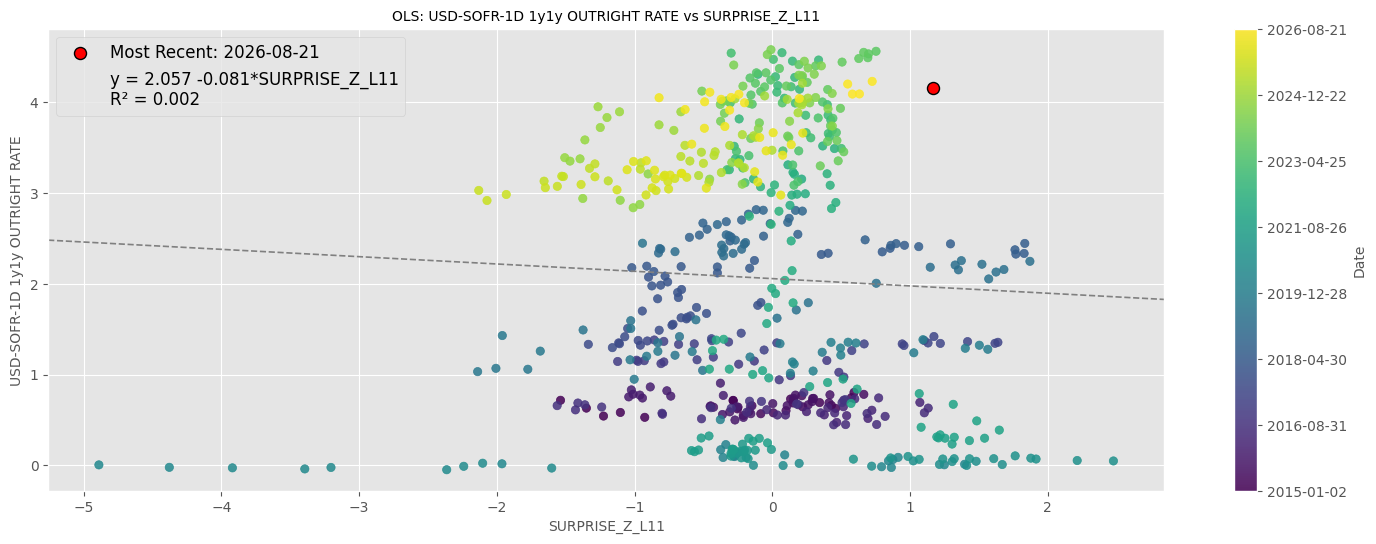

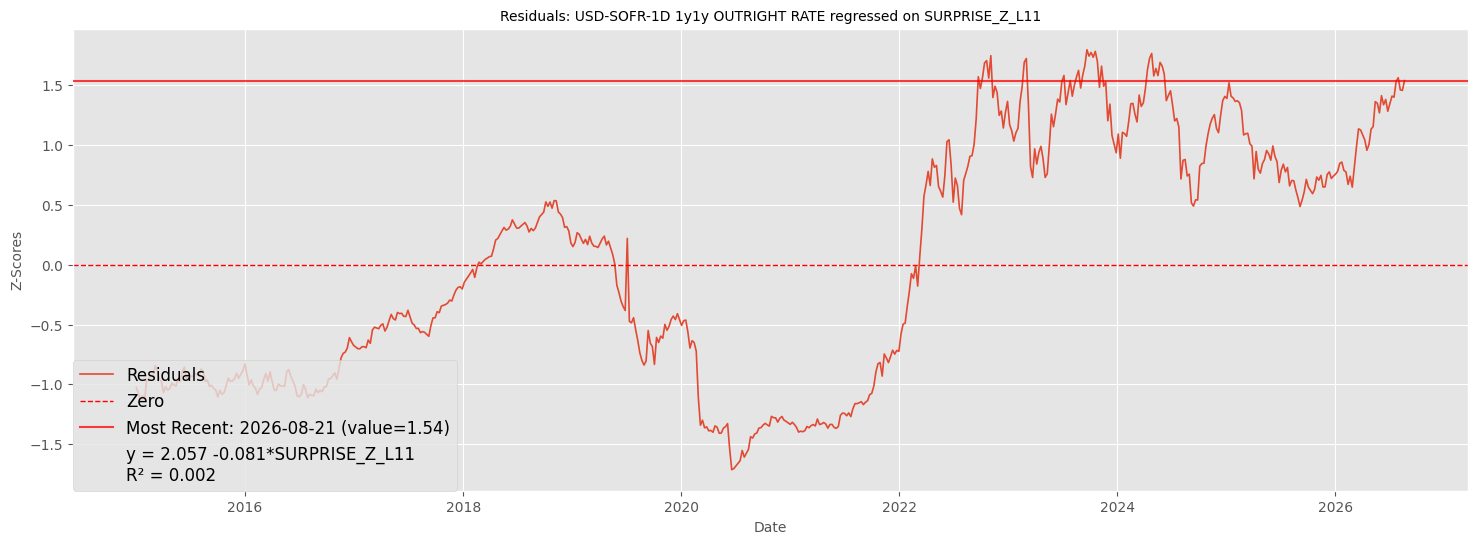


levels, Newey-West(11): slope -0.0806 %/z   t -0.43   (OLS reported t -1.19, Durbin-Watson 0.011)
   full     : slope -0.0806 %/z   t -0.43   n 608
   2015-2022: slope +0.0356 %/z   t +0.28   n 418
   2023-2026: slope +0.4447 %/z   t +5.96   n 190
   The levels slope CHANGES SIGN across these windows -- the diagnosis, not a result.


In [10]:
add_indep_var, fit, plot_actual_vs_predicted, plot_residuals_vs_predicted, \
    plot_residuals_timeseries, get_data = make_linear_regression_builder(
        df=reg_df, y_col=R_1Y1Y, date_color_bar=True)
add_indep_var("SURPRISE_Z_L11")
res_lvl = fit(model="OLS", verbose=True)
plot_actual_vs_predicted()
plot_residuals_timeseries(plot_zscores=True, plot_zero=True, ou_bands=False)

res_lvl_hac = hac(reg_df, R_1Y1Y, "SURPRISE_Z_L11", maxlags=LEAD_MEASURED)
print(f"\nlevels, Newey-West({LEAD_MEASURED}): slope "
      f"{res_lvl_hac.params['SURPRISE_Z_L11']:+.4f} %/z   "
      f"t {res_lvl_hac.tvalues['SURPRISE_Z_L11']:+.2f}   "
      f"(OLS reported t {res_lvl.tvalues['SURPRISE_Z_L11']:+.2f}, "
      f"Durbin-Watson {sm.stats.durbin_watson(res_lvl.resid):.3f})")

_lvl_slopes = {}
for _nm, _sub in (("full     ", reg_df),
                  ("2015-2022", reg_df[reg_df.index < pd.Timestamp("2023-01-01")]),
                  ("2023-2026", reg_df[reg_df.index >= pd.Timestamp("2023-01-01")])):
    _r = hac(_sub, R_1Y1Y, "SURPRISE_Z_L11", maxlags=LEAD_MEASURED)
    _lvl_slopes[_nm.strip()] = float(_r.params["SURPRISE_Z_L11"])
    print(f"   {_nm}: slope {_r.params['SURPRISE_Z_L11']:+.4f} %/z   "
          f"t {_r.tvalues['SURPRISE_Z_L11']:+.2f}   n {int(_r.nobs)}")
_signs = {np.sign(v) for v in _lvl_slopes.values()}
print("   The levels slope CHANGES SIGN across these windows -- the diagnosis, "
      "not a result." if len(_signs) > 1 else
      "   The levels slope keeps its sign across windows, but see the "
      "Durbin-Watson before reading anything into it.")

### 3b. The same in weekly CHANGES

Both sides differenced. This is the version with power: it cannot borrow a
shared trend, so whatever survives here is the lead itself.

                                  OLS Regression Results                                  
Dep. Variable:     USD-SOFR-1D 1y1y OUTRIGHT RATE   R-squared:                       0.002
Model:                                        OLS   Adj. R-squared:                  0.001
Method:                             Least Squares   F-statistic:                     1.432
Date:                            Tue, 25 Aug 2026   Prob (F-statistic):              0.232
Time:                                    12:40:44   Log-Likelihood:                 319.74
No. Observations:                             607   AIC:                            -635.5
Df Residuals:                                 605   BIC:                            -626.7
Df Model:                                       1                                         
Covariance Type:                        nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------

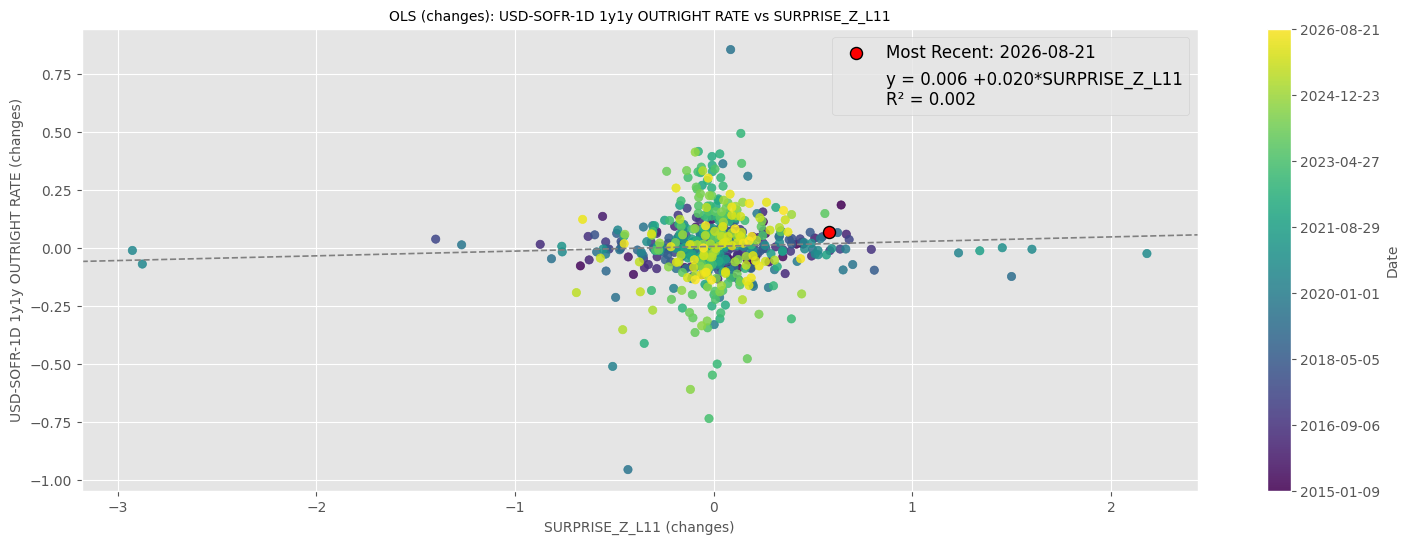


weekly changes, Newey-West(4): slope +0.0204 %/z   t +1.76   p 0.0779   n 607


In [11]:
add_indep_var, fit, plot_actual_vs_predicted, plot_residuals_vs_predicted, \
    plot_residuals_timeseries, get_data = make_linear_regression_builder(
        df=reg_df, y_col=R_1Y1Y, date_color_bar=True, on_diff=True)
add_indep_var("SURPRISE_Z_L11")
res_chg = fit(model="OLS", verbose=True)
plot_actual_vs_predicted()

_d = reg_df[[R_1Y1Y, "SURPRISE_Z_L11"]].diff().dropna()
res_chg_hac = hac(_d, R_1Y1Y, "SURPRISE_Z_L11", maxlags=4)
print(f"\nweekly changes, Newey-West(4): slope "
      f"{res_chg_hac.params['SURPRISE_Z_L11']:+.4f} %/z   "
      f"t {res_chg_hac.tvalues['SURPRISE_Z_L11']:+.2f}   "
      f"p {res_chg_hac.pvalues['SURPRISE_Z_L11']:.4f}   n {int(res_chg_hac.nobs)}")

### 3c. The horizon regression — the one the trade is

This is the spec that matches the position. For each Friday `t`:

* `y` = the **forward 11-week change in 1y1y**, in bp. A receiver profits when
  this is negative.
* `x` = the **trailing 11-week change in the composite**, fully observed at
  `t`. Both marks are Friday closes, so entry is that close; nothing on the
  right-hand side is in the future.

Windows overlap, so the plain standard error is far too small. Newey-West at
lag 11 and a **non-overlapping every-11th-week** subsample are both reported;
the second one's `n` is the honest count of independent observations.

586 overlapping windows, 2015-03-20..2026-06-05
                            OLS Regression Results                            
Dep. Variable:          FWD11_1Y1Y_BP   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     9.784
Date:                Tue, 25 Aug 2026   Prob (F-statistic):            0.00185
Time:                        12:40:44   Log-Likelihood:                -3107.5
No. Observations:                 586   AIC:                             6219.
Df Residuals:                     584   BIC:                             6228.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons

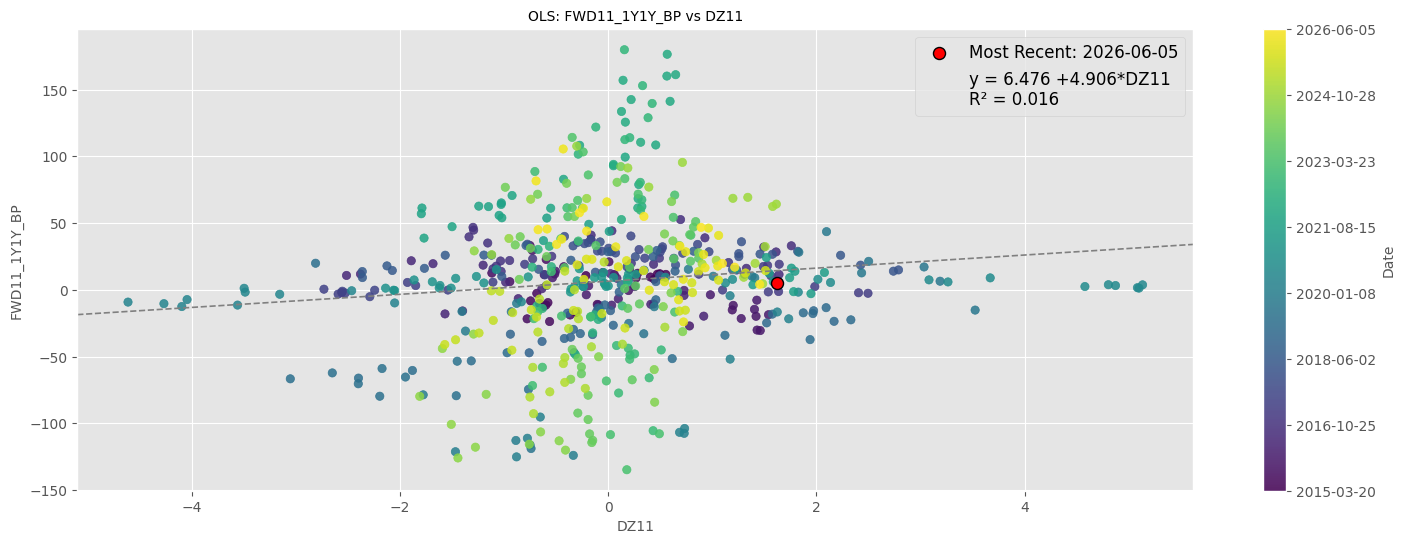


1y1y, forward 11w change on trailing 11w composite change
   overlapping, Newey-West(11): slope +4.91 bp/z   t +2.02   p 0.0430   R2 0.016   n 586
   non-overlapping every 11th week: slope +6.39 bp/z   t +1.26   p 0.2144   R2 0.029   n 54


In [12]:
H = pd.DataFrame(index=reg_df.index)
H["DZ11"] = reg_df["SURPRISE_Z"] - reg_df["SURPRISE_Z"].shift(LEAD_MEASURED)
H["FWD11_1Y1Y_BP"] = (reg_df["ONE_Y_ONE_Y_BP"].shift(-LEAD_MEASURED)
                      - reg_df["ONE_Y_ONE_Y_BP"])
H["FWD11_CURVE_BP"] = (reg_df[C_1Y_1Y1Y].shift(-LEAD_MEASURED)
                       - reg_df[C_1Y_1Y1Y])
H = H.dropna(subset=["DZ11"])
Hf = H.dropna()
print(f"{len(Hf)} overlapping windows, {Hf.index.min().date()}"
      f"..{Hf.index.max().date()}")

add_indep_var, fit, plot_actual_vs_predicted, plot_residuals_vs_predicted, \
    plot_residuals_timeseries, get_data = make_linear_regression_builder(
        df=Hf, y_col="FWD11_1Y1Y_BP", date_color_bar=True)
add_indep_var("DZ11")
res_h = fit(model="OLS", verbose=True)
plot_actual_vs_predicted()

res_h_hac = hac(Hf, "FWD11_1Y1Y_BP", "DZ11", maxlags=LEAD_MEASURED)
nov = Hf.iloc[::LEAD_MEASURED]
res_h_nov = sm.OLS(nov["FWD11_1Y1Y_BP"], sm.add_constant(nov["DZ11"])).fit()
print(f"\n1y1y, forward {LEAD_MEASURED}w change on trailing {LEAD_MEASURED}w "
      f"composite change")
print(f"   overlapping, Newey-West({LEAD_MEASURED}): slope "
      f"{res_h_hac.params['DZ11']:+.2f} bp/z   t {res_h_hac.tvalues['DZ11']:+.2f}"
      f"   p {res_h_hac.pvalues['DZ11']:.4f}   R2 {res_h_hac.rsquared:.3f}"
      f"   n {int(res_h_hac.nobs)}")
print(f"   non-overlapping every {LEAD_MEASURED}th week: slope "
      f"{res_h_nov.params['DZ11']:+.2f} bp/z   t {res_h_nov.tvalues['DZ11']:+.2f}"
      f"   p {res_h_nov.pvalues['DZ11']:.4f}   R2 {res_h_nov.rsquared:.3f}"
      f"   n {int(res_h_nov.nobs)}")

### 3d. The flattener on the same horizon spec

In [13]:
res_c_hac = hac(Hf, "FWD11_CURVE_BP", "DZ11", maxlags=LEAD_MEASURED)
res_c_nov = sm.OLS(nov["FWD11_CURVE_BP"], sm.add_constant(nov["DZ11"])).fit()
print(f"1y/1y1y, forward {LEAD_MEASURED}w change on trailing composite change")
print(f"   overlapping, Newey-West({LEAD_MEASURED}): slope "
      f"{res_c_hac.params['DZ11']:+.2f} bp/z   t {res_c_hac.tvalues['DZ11']:+.2f}"
      f"   p {res_c_hac.pvalues['DZ11']:.4f}   R2 {res_c_hac.rsquared:.3f}"
      f"   n {int(res_c_hac.nobs)}")
print(f"   non-overlapping: slope {res_c_nov.params['DZ11']:+.2f} bp/z   "
      f"t {res_c_nov.tvalues['DZ11']:+.2f}   p {res_c_nov.pvalues['DZ11']:.4f}"
      f"   n {int(res_c_nov.nobs)}")

1y/1y1y, forward 11w change on trailing composite change
   overlapping, Newey-West(11): slope +1.62 bp/z   t +1.43   p 0.1534   R2 0.005   n 586
   non-overlapping: slope +1.61 bp/z   t +0.62   p 0.5361   n 54


### 3e. Is it just the 2023-26 regime?

The same horizon regression on subsamples. If the slope is carried entirely by
the disinflation leg, the full-sample number is not the one to size off.

In [14]:
rows = []
for name, sub in (("full sample", Hf),
                  ("2015-2022", Hf[Hf.index < pd.Timestamp("2023-01-01")]),
                  ("2023-2026", Hf[Hf.index >= pd.Timestamp("2023-01-01")])):
    if len(sub) < 30:
        continue
    r = hac(sub, "FWD11_1Y1Y_BP", "DZ11", maxlags=LEAD_MEASURED)
    rows.append({"sample": name, "n": int(r.nobs),
                 "slope_bp_per_z": float(r.params["DZ11"]),
                 "t_HAC": float(r.tvalues["DZ11"]),
                 "p_HAC": float(r.pvalues["DZ11"]),
                 "R2": float(r.rsquared)})
SUB = pd.DataFrame(rows)
print(SUB.to_string(index=False))

     sample   n  slope_bp_per_z    t_HAC    p_HAC       R2
full sample 586        4.906396 2.023600 0.043011 0.016478
  2015-2022 407        2.825116 1.228328 0.219324 0.008218
  2023-2026 179       22.371639 3.037808 0.002383 0.091079


## 4. What it implies today

The trailing 11-week change in the composite is known, so the horizon fit can
be evaluated for a hold that starts now and ends in November. Two things are
reported and they are different in kind:

* the **implied move** — an implication of the fit, carrying the fit's own
  residual scatter;
* the **level residuals** — reported for completeness and *not* used
  directionally, for the reason in §3a.

In [15]:
x_now = float(H["DZ11"].dropna().iloc[-1])
z_now = float(zc.iloc[-1])
z_then = float(zc.iloc[-1 - LEAD_MEASURED])
print(f"composite {zc.index[-1 - LEAD_MEASURED].date()} {z_then:+.3f} z"
      f"  ->  {zc.index[-1].date()} {z_now:+.3f} z"
      f"   trailing {LEAD_MEASURED}w change {x_now:+.3f} z\n")

for lbl, r in (("1y1y", res_h_hac), ("1y/1y1y", res_c_hac)):
    b, a = float(r.params["DZ11"]), float(r.params["const"])
    signal_part = b * x_now
    implied = a + signal_part
    se = float(np.sqrt(r.scale))
    print(f"{lbl}: slope {b:+.2f} bp/z (t {r.tvalues['DZ11']:+.2f})")
    print(f"   what the SIGNAL contributes   {signal_part:+.1f}bp   "
          f"(= slope x {x_now:+.3f} z)")
    print(f"   unconditional {LEAD_MEASURED}w drift {a:+.1f}bp   "
          f"(the intercept -- the average move over 2015-2026, signal aside)")
    print(f"   fitted {LEAD_MEASURED}w change  {implied:+.1f}bp   "
          f"residual sd of the fit +/-{se:.0f}bp "
          f"({abs(se / signal_part):.0f}x the signal's contribution)")
    print(f"   -> the signal pushes toward the RECEIVER"
          if signal_part < 0 else "   -> the signal pushes toward the PAYER")
    print()

# the recent regime, in-sample, for contrast only
_b23 = float(hac(Hf[Hf.index >= pd.Timestamp("2023-01-01")],
                 "FWD11_1Y1Y_BP", "DZ11", maxlags=LEAD_MEASURED).params["DZ11"])
print(f"For contrast, the 2023-2026 slope alone ({_b23:+.2f} bp/z) would put the "
      f"signal's contribution at {_b23 * x_now:+.1f}bp --")
print(f"but see 3e: that is the only subsample where the slope is significant, "
      f"and it is the sample containing the move being bet on.")

composite 2026-06-05 +1.164 z  ->  2026-08-21 -0.373 z   trailing 11w change -1.537 z

1y1y: slope +4.91 bp/z (t +2.02)
   what the SIGNAL contributes   -7.5bp   (= slope x -1.537 z)
   unconditional 11w drift +6.5bp   (the intercept -- the average move over 2015-2026, signal aside)
   fitted 11w change  -1.1bp   residual sd of the fit +/-49bp (6x the signal's contribution)
   -> the signal pushes toward the RECEIVER

1y/1y1y: slope +1.62 bp/z (t +1.43)
   what the SIGNAL contributes   -2.5bp   (= slope x -1.537 z)
   unconditional 11w drift +0.1bp   (the intercept -- the average move over 2015-2026, signal aside)
   fitted 11w change  -2.4bp   residual sd of the fit +/-29bp (12x the signal's contribution)
   -> the signal pushes toward the RECEIVER

For contrast, the 2023-2026 slope alone (+22.37 bp/z) would put the signal's contribution at -34.4bp --
but see 3e: that is the only subsample where the slope is significant, and it is the sample containing the move being bet on.


In [16]:
_rl = sm.OLS(reg_df[R_1Y1Y], sm.add_constant(reg_df["SURPRISE_Z_L11"])).fit()
_rc = sm.OLS(reg_df[C_1Y_1Y1Y], sm.add_constant(reg_df["SURPRISE_Z_L11"])).fit()
print("LEVEL RESIDUALS -- reported, not used")
for lbl, r, col, unit in (("1y1y   ", _rl, R_1Y1Y, "%"),
                          ("1y/1y1y", _rc, C_1Y_1Y1Y, "bp")):
    sd = float(r.resid.std())
    fitted = float(r.predict().iloc[-1]) if hasattr(r.predict(), "iloc") \
        else float(r.predict()[-1])
    actual = float(reg_df[col].iloc[-1])
    print(f"   {lbl}  fitted {fitted:+.3f}{unit}  actual {actual:+.3f}{unit}   "
          f"residual {actual - fitted:+.3f}{unit} "
          f"({(actual - fitted) / sd:+.2f} sd), "
          f"DW {sm.stats.durbin_watson(r.resid):.3f}")
# the same residual, on a shorter window -- the sample IS the answer here
_short = reg_df[reg_df.index >= pd.Timestamp("2023-05-01")]
_rs = sm.OLS(_short[R_1Y1Y], sm.add_constant(_short["SURPRISE_Z_L11"])).fit()
def _last_resid_z(r):
    """statsmodels hands back an ndarray or a Series depending on how the
    design matrix was built; take the last residual in sd units either way."""
    e = np.asarray(r.resid, dtype=float)
    return float(e[-1] / e.std())


_zf, _zs = _last_resid_z(_rl), _last_resid_z(_rs)
print("\n   the SAME 1y1y residual, same day, two windows:")
print(f"      2015-start ({len(reg_df)}w): {_zf:+.2f} sd")
print(f"      2023-start ({len(_short)}w): {_zs:+.2f} sd")
print("      -> opposite sides of zero, from the same data on the same day."
      if _zf * _zs < 0 else
      "      -> same side of zero, but the magnitudes are not comparable.")

print("\n   Both fits have Durbin-Watson far below 2, so both residual z-scores")
print("   are unreliable -- including the 1y1y one, whichever way it reads.")
print("   Neither is evidence; the horizon fit above is what the directional")
print("   statement rests on.")

LEVEL RESIDUALS -- reported, not used
   1y1y     fitted +1.963%  actual +4.160%   residual +2.197% (+1.54 sd), DW 0.011
   1y/1y1y  fitted -12.852bp  actual +14.528bp   residual +27.380bp (+0.55 sd), DW 0.056

   the SAME 1y1y residual, same day, two windows:
      2015-start (608w): +1.54 sd
      2023-start (173w): -0.60 sd
      -> opposite sides of zero, from the same data on the same day.

   Both fits have Durbin-Watson far below 2, so both residual z-scores
   are unreliable -- including the 1y1y one, whichever way it reads.
   Neither is evidence; the horizon fit above is what the directional
   statement rests on.


### Chart 3 — where the lead points next

At a lead of L weeks the data surfacing in Fed language on a date D is the
composite as it stood L weeks before D. Positive means the data reaching
Fedspeak that week ran hot.

In [17]:
FWD = FEC.forward_read(["2026-08-28", "2026-09-16", "2026-10-28", "2026-12-09"],
                       leads_w=(5, 11, 14))
print(FWD.to_string(index=False))

import plotly.graph_objects as go

f = go.Figure()
for Lw in (5, 11, 14):
    f.add_bar(x=[str(d) for d in FWD["date"]], y=FWD[f"z_composite_at_L{Lw}"],
              name=f"lead {Lw}w")
f.add_hline(y=0, line=dict(width=2))
f.update_layout(title="What the composite implies for Fedspeak on each date "
                      "(positive = hawkish)",
                yaxis_title="composite z at the lead", height=420,
                legend=dict(orientation="h", y=1.02, x=0))
f.show()

      date  z_composite_at_L5 reads_data_of_L5  z_composite_at_L11 reads_data_of_L11  z_composite_at_L14 reads_data_of_L14
2026-08-28           0.261956       2026-07-24            0.579755        2026-06-12            0.632047        2026-05-22
2026-09-16          -0.275451       2026-08-07            0.577886        2026-06-26            1.163881        2026-06-05
2026-10-28          -0.373219       2026-08-21           -0.275451        2026-08-07           -0.000523        2026-07-17
2026-12-09          -0.373219       2026-08-21           -0.373219        2026-08-21           -0.373219        2026-08-21


## 5. Read this before sizing

The lead in §1 is a measured fact, at **11–14 weeks** rather than five, and the
overhang on the right of Charts 1 and 2 is genuinely known rather than
forecast. **The two specifications with power agree on the sign**: the weekly
changes fit (§3b, +0.0204 %/z, t 1.76) and the horizon fit (§3c, +4.91 bp/z)
both say a composite that has rolled over implies a lower 1y1y and a flatter
1y/1y1y. On direction, those two support the receiver.

The levels fit (§3a) does **not** — its full-sample slope is *negative*
(−0.08 %/z, t −0.43) and it flips positive on the 2023–2026 window. That is not
a counter-result; a Durbin-Watson of 0.011 means it was never a test. It is
recorded here because a levels fit that had happened to agree would have been
just as worthless, and it is worth seeing one that does not.

On **size** the notebook does not support the trade, and the three numbers that
say so are:

* **The honest `n` kills the t.** Overlapping windows give t 2.02 (p 0.043);
  the non-overlapping every-11th-week subsample — 54 genuinely independent
  observations — gives **t 1.26, p 0.21**. The overlapping t was counting the
  same eleven weeks eleven times.
* **The slope is one regime.** 2015–2022: slope +2.83, t 1.23, p 0.22 —
  nothing. 2023–2026: slope +22.37, t 3.04, R² 0.091. All of the relationship
  lives in the disinflation leg, which is the move the position is betting
  continues. Fitting it there and extrapolating is assuming the answer.
* **The scatter dwarfs the signal.** The signal's contribution to the next
  eleven weeks is **−7.5bp** on 1y1y against a residual sd of **±49bp** — a
  factor of six — and **−2.5bp against ±29bp** on the flattener, a factor of
  twelve. That ratio, not the sign, is what sizing keys off, and it is also why
  the flattener is the worse of the two ways to hold this view.

The surrounding evidence points the same way. Across four merged studies
(#490, #491, #497, #501) the end-to-end `data → price` link is dead — 2,048
cells in one, three samples in another, and in every one the best searched cell
sat **below the median of its own rotation null**. §3c is a regression, not a
backtest, and a slope that passes a t-test is not a rule that survives a null.
The one link never measured — `language → price` at communication events —
comes out positive at about **+2bp of priced path per sd of sentiment**,
consistent across two independent judge models and **not distinguishable from
zero**: t 0.46–1.18 on 44–98 events.

The level residuals in §4 make the same point from the other side, and the
notebook computes the demonstration rather than asserting it: the **same**
1y1y level residual, on the **same day**, is printed for a 2015-start window
and a 2023-start one. Same instrument, same signal, opposite conclusion —
because the sample changed. A residual that does that is a sample artefact,
and it is inadmissible whichever way it happens to point.

And the timing cuts against the near date rather than for it: at every measured
lead the data reaching Fed language at **Jackson Hole and the September FOMC is
hot**. The dovish convergence lands **late October into December**.

So: hold the receiver on the macro view. This notebook is entitled to set the
**clock** — December, not Friday — and to confirm the **sign**. It is not
entitled to set the size, and a levels R² does not stand in for an edge.